In [1]:
import pandas as pd
from lib.metrics import *
from lib.model_loading import load_predictions

## Ensemble results


In [2]:
def return_all_metrics(ensemble_name, ensemble_type):
    all_predictions = load_predictions(ensemble_name, predictions_folder=f"predictions/results_{ensemble_type}")
    ensemble_predictions, true_values = all_predictions

    mean_of_means, combined_log_variances = compute_combined_parameters(
        ensemble_predictions
    )

    return calculate_all_metrics(ensemble_predictions, true_values)


def format_results(ensemble_results):
    formatted_results = []

    for name, result in ensemble_results.items():
        formatted_result = {
            'Name': name,
            'Combined NLL': round(result['combined_nll'].item(), 2),
            'PICP': round(result['intervals'][0], 3),
            'PIW': round(result['intervals'][1], 3),
            'Pearson Correlation (Predictions)': round(result['correlations_predictions']['pearson_corr'], 4),
            'Spearman Correlation (Predictions)': round(result['correlations_predictions']['spearman_corr'], 4),
            'Pearson Correlation (Uncertainty)': round(result['correlations_uncertainty']['pearson_corr'], 4),
            'Pearson Correlation (Uncertainty)': round(result['correlations_uncertainty']['spearman_corr'], 4),
        }
        formatted_results.append(formatted_result)

    return pd.DataFrame(formatted_results)

In [3]:
ensemble_results_nll = {
    "Deep": return_all_metrics("deep", "hetero"),
    "Hyperdeep": return_all_metrics("hyperdeep", "hetero"),
    "Dropout": return_all_metrics("dropout", "hetero"),
    "CV": return_all_metrics("cv", "hetero"),
}

ensemble_results_l2 = {
    "Deep": return_all_metrics("deep", "homo"),
    "Hyperdeep": return_all_metrics("hyperdeep", "homo"),
    "Dropout": return_all_metrics("dropout", "homo"),
    "CV": return_all_metrics("cv", "homo"),
}

In [4]:
format_results(ensemble_results_nll)

,Name,Combined NLL,PICP,PIW,Pearson Correlation (Predictions),Spearman Correlation (Predictions),Pearson Correlation (Uncertainty)
0,Deep,-1.24,0.947,0.673,0.5008,0.5195,0.0340
1,Hyperdeep,-1.24,0.950,0.684,0.4415,0.4561,0.0279
2,Dropout,-1.24,0.950,0.696,0.5035,0.5199,0.0374
3,CV,-1.24,0.943,0.663,0.5043,0.5230,0.1220


In [5]:
format_results(ensemble_results_l2)

,Name,Combined NLL,PICP,PIW,Pearson Correlation (Predictions),Spearman Correlation (Predictions),Pearson Correlation (Uncertainty)
0,Deep,237.69,0.273,0.066,0.8597,0.7980,-0.0048
1,Hyperdeep,163.74,0.332,0.076,0.8620,0.7998,-0.0421
2,Dropout,217.26,0.299,0.067,0.8613,0.7989,-0.0452
3,CV,266.23,0.255,0.061,0.8584,0.7971,-0.0085


In [31]:
all_predictions = load_predictions("dropout", predictions_folder="predictions/results_hetero")
ensemble_predictions, true_values = all_predictions

mean_of_means, combined_log_variances = compute_combined_parameters(
    ensemble_predictions
)

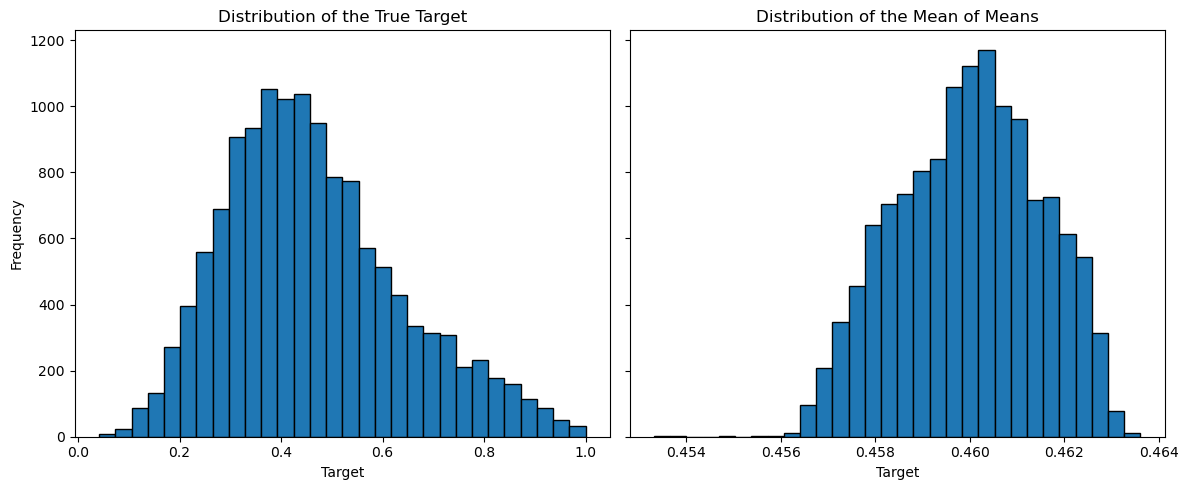

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure and subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Plotting the distribution of the true target
axes[0].hist(true_values.numpy(), bins=30, edgecolor='black')
axes[0].set_title('Distribution of the True Target')
axes[0].set_xlabel('Target')
axes[0].set_ylabel('Frequency')

# Plotting the distribution of the mean of means
axes[1].hist(mean_of_means.numpy(), bins=30, edgecolor='black')
axes[1].set_title('Distribution of the Mean of Means')
axes[1].set_xlabel('Target')

# Adjust layout
plt.tight_layout()
plt.show()


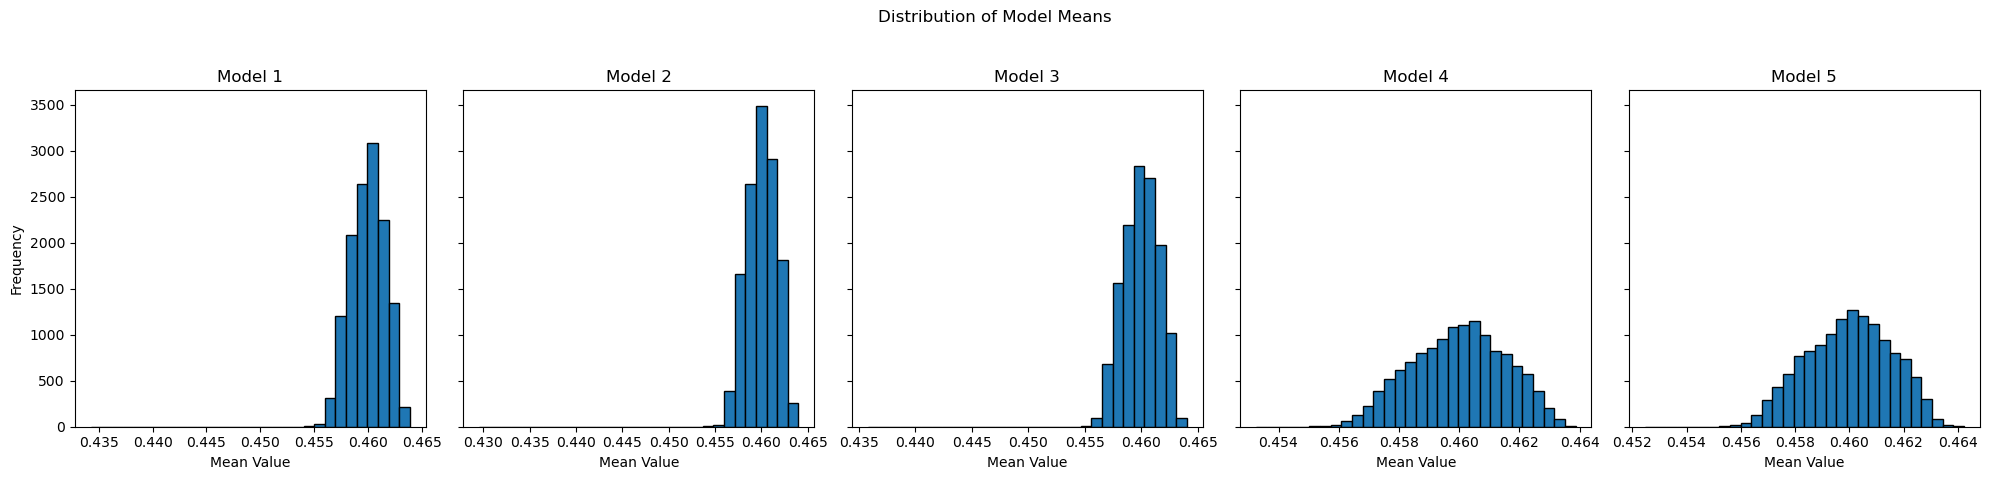

In [33]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)

for i, model_predictions in enumerate(ensemble_predictions):
    means = model_predictions[0]
    axes[i].hist(means, bins=30, edgecolor='black')
    axes[i].set_title(f'Model {i+1}')
    axes[i].set_xlabel('Mean Value')
    if i == 0:
        axes[i].set_ylabel('Frequency')

fig.suptitle('Distribution of Model Means')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


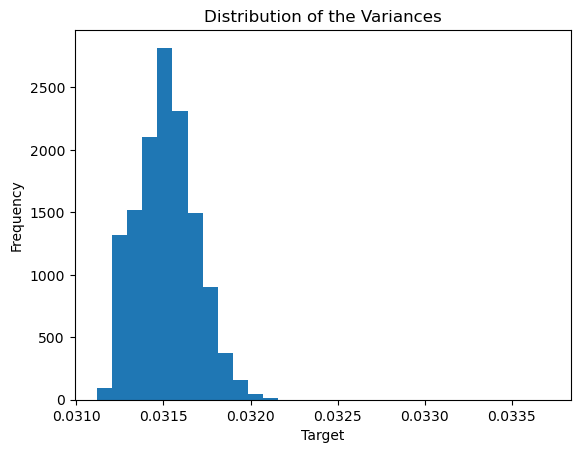

In [34]:
import matplotlib.pyplot as plt

plt.hist(np.exp(combined_log_variances).numpy(), bins=30)

plt.title('Distribution of the Variances')
plt.xlabel('Target')
plt.ylabel('Frequency')
plt.show()

In [35]:
# import matplotlib.pyplot as plt
# import numpy as np

# fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)

# for i, model_predictions in enumerate(ensemble_predictions):
#     variances = np.exp(model_predictions[1])
#     axes[i].hist(variances, bins=30, edgecolor='black')
#     axes[i].set_title(f'Model {i+1}')
#     axes[i].set_xlabel('Variance Value')
#     if i == 0:
#         axes[i].set_ylabel('Frequency')

# fig.suptitle('Distribution of Model Means')
# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.show()

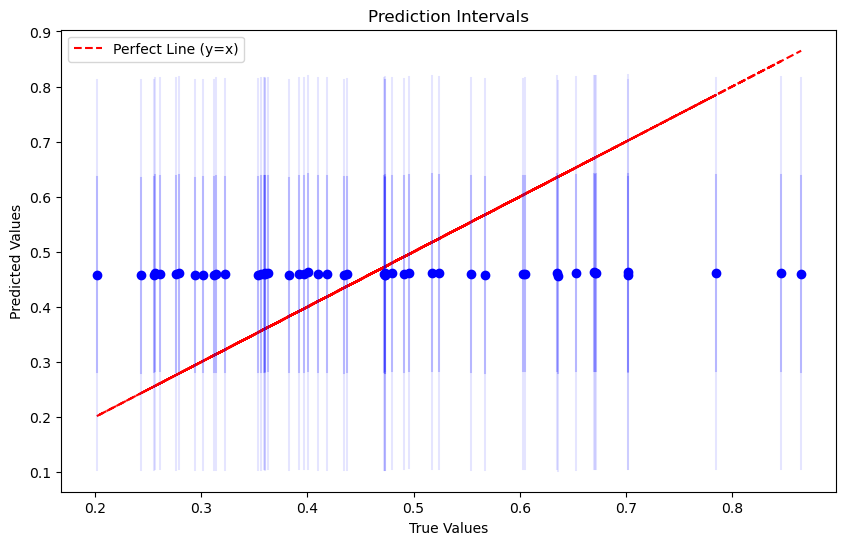

In [36]:
variances = torch.exp(combined_log_variances)

visualize_intervals(true_values.numpy(), mean_of_means.numpy(), variances.numpy(), num_points=50)